*© 2026 Paul Fergus*

# Lab 10 — Instance segmentation: from boxes to masks

**Module:** 7144COMP — Deep Learning Concepts and Techniques
**Week:** 10
**Estimated time:** 240 minutes

---

## ⚠ Requirements

This lab needs a **CUDA GPU** and your **annotated dataset from Lab 6** — complete Lab 6 first. It downloads a pretrained **Segment Anything Model (SAM)** checkpoint (~150 MB) on first use.

## Learning outcomes

By the end of this lab you should be able to:

1. Distinguish **classification**, **detection**, **semantic segmentation**, and **instance segmentation**, and state what extra information each level produces.
2. Explain **box-prompted segmentation** and use a pretrained Segment Anything Model (SAM) to convert existing bounding-box annotations into pixel-accurate masks, with no additional manual drawing.
3. Build a valid **YOLO-seg** dataset — polygon-format labels and a segmentation `data.yaml` — from SAM's output.
4. Fine-tune a **YOLO26-seg** model with Ultralytics and interpret its combined box + mask output.
5. Compute **mask IoU** from first principles and explain why mask-based and box-based localisation metrics can diverge for the same prediction.
6. Critically audit machine-generated labels for errors — a foundation model's output is a *first draft*, not automatically ground truth.

## Prerequisites

- **Lab 6** — the annotated dataset and `data.yaml` this lab extends.
- **Lab 7** — comfort with the Ultralytics training API (`model.train()`, `model.val()`, `model.predict()`).
- **Lab 8** — IoU and mAP from first principles; we extend both to masks today.
- The textbook *Applied Deep Learning* (Fergus & Chalmers), Chapter 7.
- Lecture 10: *From boxes to pixels — instance segmentation and promptable foundation models*.

## The thread from last week

Lab 9 closed with a hint about where this module goes next: *"instance segmentation (YOLOE does it too — try `results[0].masks`)."* Today we follow that thread properly. A bounding box tells you roughly *where* an object is — but it also includes every background pixel caught inside the rectangle. An elephant's box includes grass, shadow, maybe part of another animal. A **mask** tells you *exactly which pixels* belong to the elephant and no others. That precision matters whenever you need to measure an object's true shape or size, separate two overlapping animals, or reason about occlusion.

The catch: masks are far more expensive to annotate by hand than boxes — tracing a precise outline takes minutes per object, not seconds. Today we sidestep that cost entirely by using a **foundation model** (in the spirit of Lab 9) to generate masks automatically from the boxes you already have.

## Useful references

- Kirillov et al. (2023), *Segment Anything* — the SAM paper.
- Kirillov et al. (2019), *Panoptic Segmentation* — the paper that formalised semantic vs. instance vs. panoptic segmentation.
- [Ultralytics segmentation task documentation](https://docs.ultralytics.com/tasks/segment/)
- [Ultralytics SAM documentation](https://docs.ultralytics.com/models/sam/)

---

## 1. From boxes to pixels — what segmentation adds

| Task | Output | Answers |
|---|---|---|
| Classification (Labs 3–5) | one label per image | "what is the main subject?" |
| Detection (Labs 6–9) | boxes + class + confidence | "what, and roughly where, and how many?" |
| **Semantic segmentation** | one class label **per pixel** | "which pixels belong to *any* zebra?" (all zebras merged into one blob) |
| **Instance segmentation** (today) | one class label **and one identity per pixel** | "which pixels belong to *this specific* zebra, as opposed to that other zebra?" |
| Panoptic segmentation | every pixel labelled — "stuff" classes (sky, grass) semantically, "thing" classes (animals) per-instance | the full scene, unified |

Semantic segmentation alone cannot separate three zebras standing together in a herd — they'd all be painted the same "zebra" colour with no boundary between them. **Instance segmentation** keeps detection's notion of individual objects (one row per animal, like your Lab 6 boxes) but replaces the box with a precise pixel mask. That is exactly what YOLO26-**seg** — the model we train today — predicts: for every detected object, a class, a confidence, a box, *and* a mask.

**Why go to the trouble?** Three concrete reasons that come up constantly in applied work:

- **Accurate area and shape.** A box's area is a poor proxy for an animal's real size — it also counts background. A mask gives you the actual pixel footprint.
- **Overlapping or touching objects.** Two boxes for two overlapping animals overlap too; two masks don't (each pixel belongs to at most one instance).
- **Downstream reasoning.** Cropping just the animal (not its background) for a species classifier, measuring body condition, occlusion-aware tracking — all need pixels, not rectangles.

## 2. Point at your dataset

This runs SAM over your full annotated pool from Lab 6. Every image needs its own SAM call, so expect roughly 30-40 minutes for mask generation on a mid-range GPU — not the under-a-minute turnaround a small pool would give you, but a one-off cost.

In [3]:
from pathlib import Path
import yaml

SRC_DATA_YAML = Path("../lab06_image_annotation/data/data.yaml")
if not SRC_DATA_YAML.is_file():
    raise FileNotFoundError(
        "No source dataset found. Complete Lab 6 Sections 1-5 first."
    )
SRC_DATA_YAML = SRC_DATA_YAML.resolve()

with open(SRC_DATA_YAML) as f:
    src_cfg = yaml.safe_load(f)

CLASSES = src_cfg["names"]
if isinstance(CLASSES, dict):
    CLASSES = [CLASSES[i] for i in sorted(CLASSES.keys())]

SRC_ROOT = Path(src_cfg["path"])
print(f"Source dataset: {SRC_DATA_YAML}")
print(f"Classes: {CLASSES}")
for split in ("train", "val", "test"):
    n = len(list((SRC_ROOT / src_cfg[split]).glob("*.jpg")))
    print(f"  {split}: {n} images")

Source dataset: /workspace/labs/lab06_image_annotation/data/data.yaml
Classes: ['buffalo', 'elephant', 'rhino', 'zebra']
  train: 1052 images
  val: 225 images
  test: 227 images


## 3. Segment Anything — box-prompted mask generation

**SAM** (Segment Anything Model) is a foundation model trained on over a billion masks across 11 million images. It was never shown a buffalo, elephant, rhino, or zebra by name — it does not know class labels at all. What it learned instead is a much more general skill: **given an image and a prompt indicating roughly where an object is (a point, or a box), trace the precise pixel boundary of that object.**

That is exactly what we need. You already told the model roughly where every animal is, in Lab 6 — that's what your boxes encode. We now hand each box to SAM as a prompt and ask it to refine that rectangle into a pixel-accurate mask.

> **First run downloads the checkpoint** (~150 MB for the base SAM2 model). If `"sam2_b.pt"` isn't recognised by your `ultralytics` version, try `"sam_b.pt"` (the original SAM) or check <https://docs.ultralytics.com/models/sam/> for the current checkpoint names — the box-prompt API below is the same either way.

In [4]:
from ultralytics import SAM

SAM_CHECKPOINT = "sam2_b.pt"
sam = SAM(SAM_CHECKPOINT)
print(f"Loaded {SAM_CHECKPOINT}")
print(f"Task: {sam.task}")

Loaded sam2_b.pt
Task: segment


### Generate a mask for every ground-truth box

For each image, we read its YOLO box labels (exactly as in Lab 6/8), convert them to pixel `[x1,y1,x2,y2]`, and hand the *whole list* of boxes for that image to SAM in one call as `bboxes=`. SAM returns one mask per box, in the same order. We keep both the raw boolean mask (for overlays and IoU later) and the polygon outline SAM already traced (`.masks.xy`, in pixel coordinates) — we'll need that in Section 5.

> This loop calls SAM once per image. On a mid-range GPU, expect roughly 1–2 seconds per image — a 15-image dataset finishes in well under a minute; your own larger dataset will take longer. This is a one-off cost: masks only need generating once.

In [5]:
from PIL import Image
import numpy as np
import pickle

def load_boxes_xyxy(img_path: Path, label_path: Path):
    """Read a YOLO box-format label file. Returns [(class_id, [x1,y1,x2,y2]), ...] in pixels."""
    if not label_path.is_file():
        return []
    with Image.open(img_path) as im:
        W, H = im.size
    boxes = []
    for line in label_path.read_text().splitlines():
        if not line.strip():
            continue
        cls, cx, cy, w, h = line.split()
        cls = int(cls); cx, cy, w, h = map(float, (cx, cy, w, h))
        x1, y1 = (cx - w/2) * W, (cy - h/2) * H
        x2, y2 = (cx + w/2) * W, (cy + h/2) * H
        boxes.append((cls, [x1, y1, x2, y2]))
    return boxes


def generate_masks_for_split(split: str):
    """Box-prompt SAM with every ground-truth box in a split.
    Returns {stem: [(class_id, mask_bool_HxW, polygon_xy_pixels), ...]}.
    """
    img_dir = SRC_ROOT / src_cfg[split]
    lbl_dir = SRC_ROOT / src_cfg[split].replace("images", "labels")
    out = {}
    for img_path in sorted(img_dir.glob("*.jpg")):
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        boxes = load_boxes_xyxy(img_path, lbl_path)
        if not boxes:
            out[img_path.stem] = []
            continue
        xyxy = [b for _, b in boxes]
        results = sam.predict(source=str(img_path), bboxes=xyxy, verbose=False)
        r = results[0]
        masks_bool = r.masks.data.cpu().numpy().astype(bool)   # (n_boxes, H, W)
        polygons = r.masks.xy                                   # list of (n_i, 2) pixel arrays
        out[img_path.stem] = [
            (cls, masks_bool[i], polygons[i]) for i, (cls, _) in enumerate(boxes)
        ]
    return out


# SAM generation takes ~30-40 minutes over the full pool — cache the result
# to disk so a kernel restart (or just re-running the notebook) doesn't
# force you to pay that cost again. Masks are bit-packed before pickling
# (8x smaller) since a boolean HxW array per instance adds up fast.
MASKS_CACHE = Path("data/.sam_masks_cache.pkl")
FORCE_REGENERATE_MASKS = False  # set True to ignore the cache and re-run SAM from scratch

def _pack_masks(masks_dict):
    return {
        split: {
            stem: [(cls, np.packbits(mask), mask.shape, poly) for cls, mask, poly in entries]
            for stem, entries in stems.items()
        }
        for split, stems in masks_dict.items()
    }

def _unpack_masks(packed_dict):
    return {
        split: {
            stem: [
                (cls, np.unpackbits(packed, count=shape[0] * shape[1]).reshape(shape).astype(bool), poly)
                for cls, packed, shape, poly in entries
            ]
            for stem, entries in stems.items()
        }
        for split, stems in packed_dict.items()
    }


if MASKS_CACHE.is_file() and not FORCE_REGENERATE_MASKS:
    print(f"Found cached SAM masks at {MASKS_CACHE} — skipping SAM generation (~30-40 minutes saved).")
    print("Set FORCE_REGENERATE_MASKS = True above (or delete the cache file) to regenerate from scratch.")
    with open(MASKS_CACHE, "rb") as f:
        all_masks = _unpack_masks(pickle.load(f))
    for split in ("train", "val", "test"):
        n_masks = sum(len(v) for v in all_masks[split].values())
        print(f"{split}: {n_masks} masks across {len(all_masks[split])} images (from cache)")
else:
    all_masks = {}
    for split in ("train", "val", "test"):
        split_masks = generate_masks_for_split(split)
        all_masks[split] = split_masks
        n_masks = sum(len(v) for v in split_masks.values())
        print(f"{split}: generated {n_masks} masks across {len(split_masks)} images")
    MASKS_CACHE.parent.mkdir(parents=True, exist_ok=True)
    with open(MASKS_CACHE, "wb") as f:
        pickle.dump(_pack_masks(all_masks), f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"\nCached masks to {MASKS_CACHE} for next time.")

Found cached SAM masks at data/.sam_masks_cache.pkl — skipping SAM generation (~30-40 minutes saved).
Set FORCE_REGENERATE_MASKS = True above (or delete the cache file) to regenerate from scratch.
train: 1911 masks across 1052 images (from cache)
val: 377 masks across 225 images (from cache)
test: 397 masks across 227 images (from cache)


## 4. Visual audit — always look at what the foundation model gave you

Same discipline as every previous lab: **never trust an annotation, human or machine, that you haven't looked at.** Overlay the generated masks on their source images.

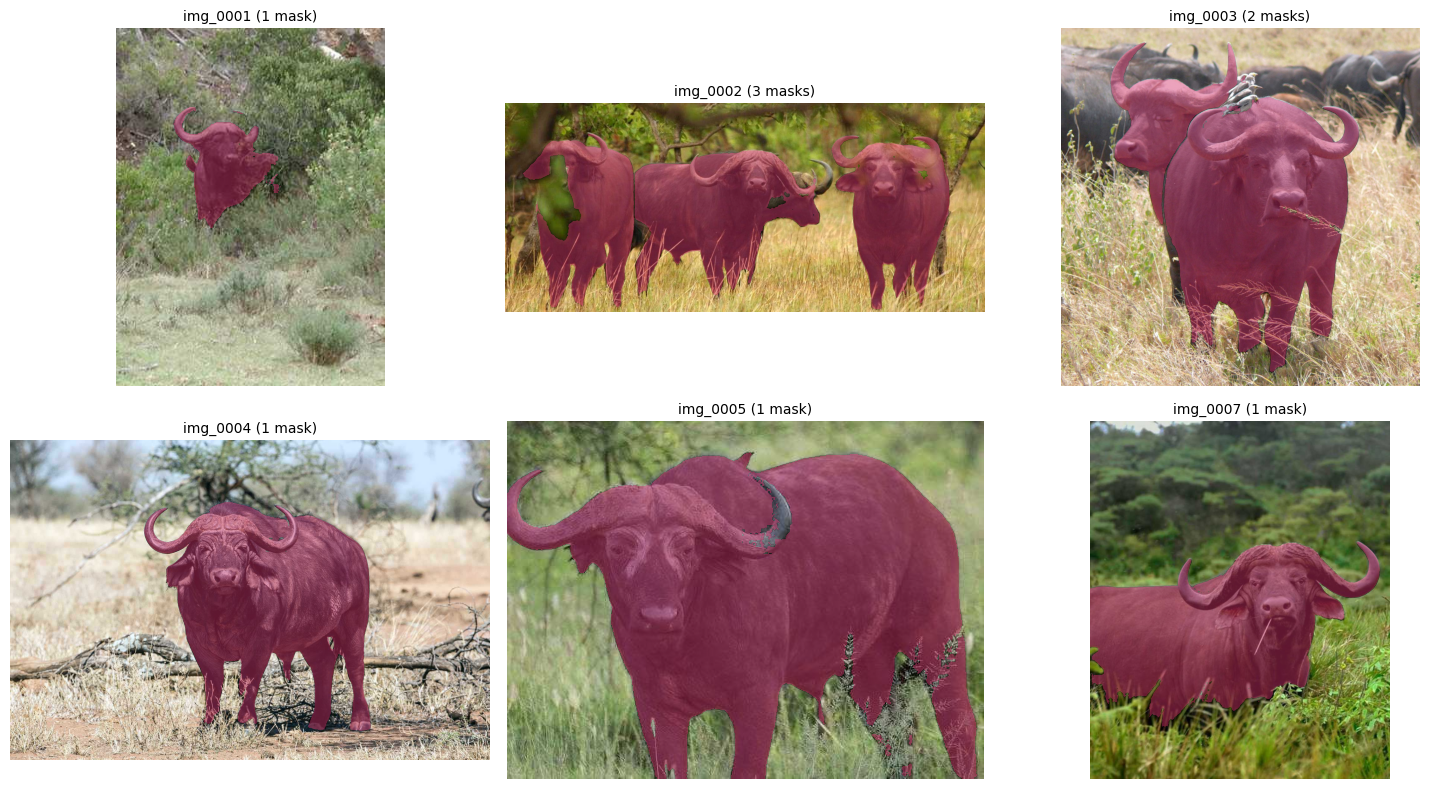

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

CLASS_COLOURS = {i: c for i, c in enumerate(
    ["#d6336c", "#f59f00", "#2b8a3e", "#1c7ed6"][:len(CLASSES)]
)}

def hex_to_rgb(colour_hex):
    h = colour_hex.lstrip("#")
    return tuple(int(h[i:i+2], 16) / 255 for i in (0, 2, 4))

def show_masks(split, stem, ax=None):
    img_path = SRC_ROOT / src_cfg[split] / f"{stem}.jpg"
    img = Image.open(img_path)
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    ax.imshow(img); ax.axis("off")
    overlay = np.zeros((img.size[1], img.size[0], 4))
    for cls_id, mask, _ in all_masks[split].get(stem, []):
        rgb = hex_to_rgb(CLASS_COLOURS.get(cls_id, "#888888"))
        overlay[mask] = (*rgb, 0.45)
    ax.imshow(overlay)
    n = len(all_masks[split].get(stem, []))
    ax.set_title(f"{stem} ({n} mask{'s' if n != 1 else ''})", fontsize=10)

sample_stems = list(all_masks["train"].keys())[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, stem in zip(axes.flat, sample_stems):
    show_masks("train", stem, ax=ax)
for ax in axes.flat[len(sample_stems):]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

**What to look for.** The mask should hug the animal's true silhouette — legs, ears, tail included, background excluded. Common SAM failure modes to watch for (you'll audit these properly in Exercise 1):

- The mask bleeds into background that shares the animal's colour or texture.
- The mask captures only part of the animal (e.g. the body but not an outstretched leg).
- Two touching or overlapping animals get merged into one mask, or one mask "steals" part of its neighbour.

Any of these would silently poison your training labels if you trained on them without looking. This is the same lesson as Lab 6's annotation hygiene — the source of the label (human or foundation model) doesn't change the rule.

## 5. From masks to YOLO-seg labels

The **YOLO-seg** label format extends the detection format you met in Lab 6. Instead of a fixed 5 numbers (`class cx cy w h`), each line is a **variable-length polygon**:

```
class_id  x1 y1  x2 y2  x3 y3  ...  xn yn
```

Every `(x, y)` pair is a point on the object's outline, normalised to `[0, 1]` exactly like the box coordinates were. More points trace a more precise outline; the polygon can have as many vertices as needed.

We don't need to trace this outline ourselves — `results[0].masks.xy` (captured in Section 3) is *already* a pixel-coordinate polygon that Ultralytics extracted from SAM's mask. All that's left is to normalise it by image size and write it out in this format, exactly the mechanical step Lab 6 did for boxes.

**One catch: SAM's traced contour is far denser than a label needs.** It follows every pixel-level wiggle of the mask boundary — a single animal's outline can easily have 1,000+ points. A YOLO-seg label doesn't need that precision (20-100 points traces a perfectly usable outline for training), and leaving it untouched bloats every label file, which in turn bloats how much memory Ultralytics' data loader needs to hold your dataset — enough, across a large dataset, to be a real cause of an out-of-memory crash. We uniformly subsample each polygon down to a sane maximum before writing it.

In [7]:
import shutil

def simplify_polygon(poly: np.ndarray, max_points: int = 100) -> np.ndarray:
    """Uniformly subsample a polygon down to at most max_points vertices.
    SAM's traced contour can have thousands of points; a YOLO-seg label
    only needs enough to trace a recognisable outline, and keeping every
    point bloats label files (and the memory needed to load them) for
    no benefit — see the note above.
    """
    n = len(poly)
    if n <= max_points:
        return poly
    idx = np.linspace(0, n - 1, max_points).round().astype(int)
    idx = np.unique(idx)
    return poly[idx]


OUT_ROOT = Path("data")
# Clear any stale images/labels from a previous run of this notebook so
# this run's output isn't silently merged with leftovers.
for sub in ("images", "labels"):
    if (OUT_ROOT / sub).is_dir():
        shutil.rmtree(OUT_ROOT / sub)
for split in ("train", "val", "test"):
    (OUT_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUT_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

n_written, n_skipped = 0, 0
for split in ("train", "val", "test"):
    src_img_dir = SRC_ROOT / src_cfg[split]
    for img_path in sorted(src_img_dir.glob("*.jpg")):
        with Image.open(img_path) as im:
            W, H = im.size
        shutil.copy2(img_path, OUT_ROOT / "images" / split / img_path.name)

        lines = []
        for cls_id, mask, polygon in all_masks[split].get(img_path.stem, []):
            if polygon is None or len(polygon) < 3:
                n_skipped += 1
                continue
            polygon = simplify_polygon(polygon)
            norm = polygon / np.array([W, H])
            coords = " ".join(f"{v:.6f}" for v in norm.flatten())
            lines.append(f"{cls_id} {coords}")
            n_written += 1
        (OUT_ROOT / "labels" / split / f"{img_path.stem}.txt").write_text("\n".join(lines))

print(f"Wrote {n_written} polygon labels, skipped {n_skipped} (empty or degenerate mask).")

Wrote 2685 polygon labels, skipped 0 (empty or degenerate mask).


In [8]:
seg_data_yaml = {
    "path": str(OUT_ROOT.resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {i: name for i, name in enumerate(CLASSES)},
}
seg_yaml_path = OUT_ROOT / "data.yaml"
with open(seg_yaml_path, "w") as f:
    yaml.safe_dump(seg_data_yaml, f, sort_keys=False)

print(f"Wrote {seg_yaml_path}\n")
print(seg_yaml_path.read_text())

Wrote data/data.yaml

path: /workspace/labs/lab10_instance_segmentation/data
train: images/train
val: images/val
test: images/test
names:
  0: buffalo
  1: elephant
  2: rhino
  3: zebra



## 6. Sanity check — close the loop before spending GPU time

Read the polygon files back and render them on top of their images. If the box→SAM→polygon→file pipeline has a bug (an off-by-one, a wrong normalisation), this is where it shows up — cheaply, before an hour of training makes the mistake expensive to discover.

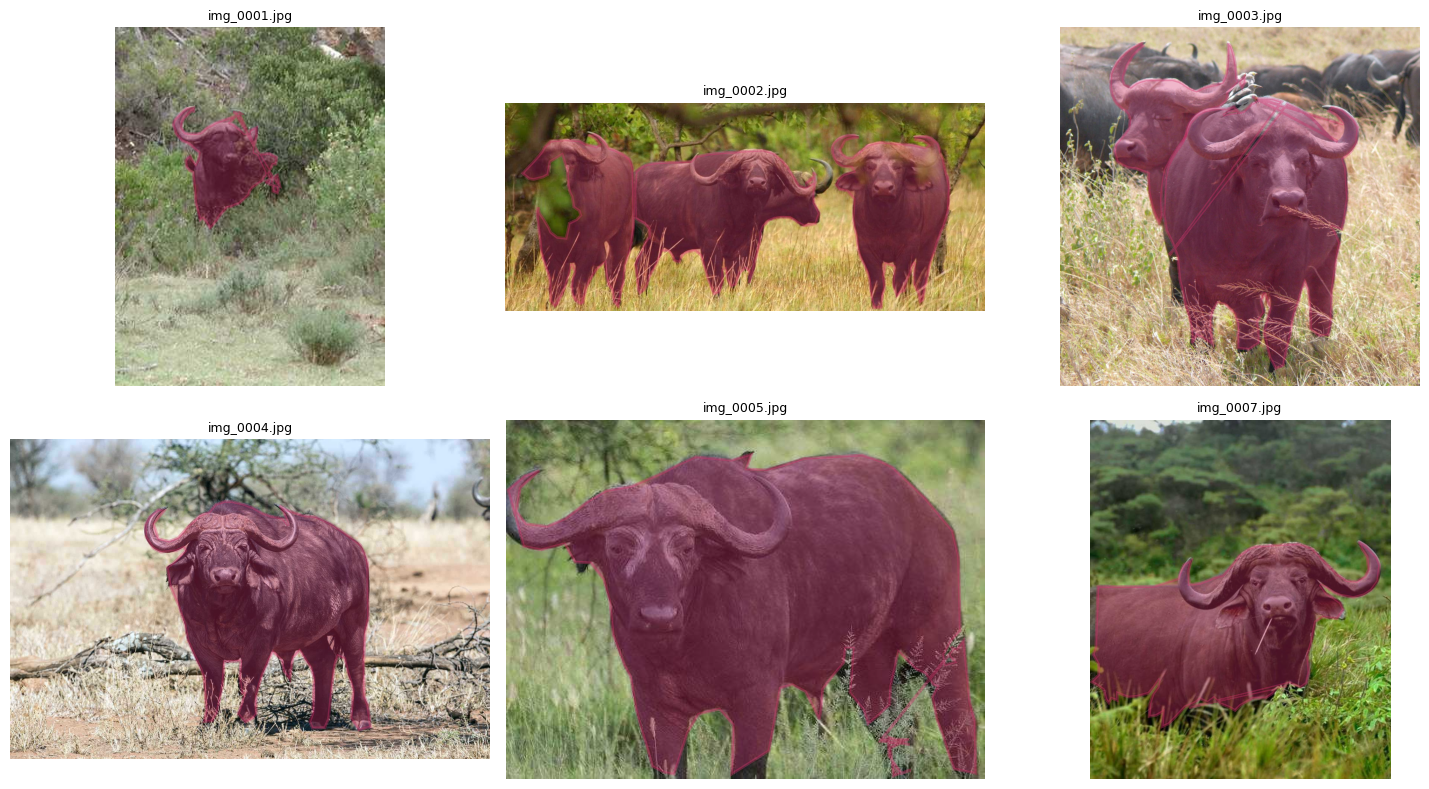

In [9]:
def read_yolo_seg_labels(label_path: Path):
    if not label_path.is_file():
        return []
    out = []
    for line in label_path.read_text().splitlines():
        if not line.strip():
            continue
        parts = line.split()
        cls_id = int(parts[0])
        pts = np.array(list(map(float, parts[1:]))).reshape(-1, 2)
        out.append((cls_id, pts))
    return out


sample_imgs = sorted((OUT_ROOT / "images" / "train").glob("*.jpg"))[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, img_path in zip(axes.flat, sample_imgs):
    img = Image.open(img_path)
    W, H = img.size
    ax.imshow(img); ax.axis("off"); ax.set_title(img_path.name, fontsize=9)
    for cls_id, pts_norm in read_yolo_seg_labels(OUT_ROOT / "labels" / "train" / f"{img_path.stem}.txt"):
        pts_px = pts_norm * np.array([W, H])
        colour = CLASS_COLOURS.get(cls_id, "#888888")
        poly = patches.Polygon(pts_px, closed=True, edgecolor=colour,
                                facecolor=colour, alpha=0.35, linewidth=2)
        ax.add_patch(poly)
for ax in axes.flat[len(sample_imgs):]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

## 7. GPU check

Same requirement as Lab 7 — segmentation training needs a CUDA GPU.

In [10]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    raise RuntimeError(
        "No CUDA device found. See Lab 7 Section 1 for the checklist "
        "(driver, NVIDIA Container Toolkit, docker-compose.yml GPU block)."
    )

props = torch.cuda.get_device_properties(0)
print(f"GPU: {props.name}  ({props.total_memory / 1e9:.1f} GB)")

PyTorch version: 2.11.0+cu128
CUDA available:  True
GPU: NVIDIA GeForce RTX 5090  (34.2 GB)


## 8. Training a YOLO26-seg model

Segmentation checkpoints follow the same size-variant naming as detection, with a `-seg` suffix: `yolo26n-seg.pt` through `yolo26x-seg.pt`. A segmentation head is heavier than a detection head — for every predicted box it must also produce a full-resolution mask — so training and inference are both slower than the equivalent detection model at the same size. Lab 7 used `yolo26x` throughout to learn the workflow at full scale; here we default to the **medium** variant instead, and leave the size trade-off for Exercise 3.

Every other parameter below means exactly what it meant in Lab 7 — same optimizer, same augmentation pipeline, same early stopping. The only thing that changed is that our `data.yaml` now points at polygon labels instead of box labels, and Ultralytics infers `task="segment"` from the `-seg` checkpoint we loaded.

**Resuming a later session?** The cell below is a safe starting point on its own — it reloads everything Sections 8 onward need straight from disk (imports, dataset config, helper functions), so if you already ran Sections 1-7 once, you can restart the kernel and jump straight here without redoing any of the SAM/dataset-build work.

In [11]:
# Reloads everything Sections 8 onward need straight from disk, so a fresh
# kernel can jump here without re-running Sections 1-7's SAM/training pipeline.
from pathlib import Path
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ultralytics import YOLO

OUT_ROOT = Path("data")
seg_yaml_path = OUT_ROOT / "data.yaml"
assert seg_yaml_path.is_file(), (
    f"{seg_yaml_path} not found — run Sections 1-6 at least once first."
)

with open(seg_yaml_path) as f:
    seg_cfg = yaml.safe_load(f)
CLASSES = [seg_cfg["names"][i] for i in sorted(seg_cfg["names"].keys())]
CLASS_COLOURS = {i: c for i, c in enumerate(["#d6336c", "#f59f00", "#2b8a3e", "#1c7ed6"][:len(CLASSES)])}


def read_yolo_seg_labels(label_path: Path):
    if not label_path.is_file():
        return []
    out = []
    for line in label_path.read_text().splitlines():
        if not line.strip():
            continue
        parts = line.split()
        cls_id = int(parts[0])
        pts = np.array(list(map(float, parts[1:]))).reshape(-1, 2)
        out.append((cls_id, pts))
    return out


# Sanity check: images/<split> and labels/<split> should have matched counts.
# If data/ got rebuilt (Section 5 re-run, possibly in a different session or
# tab) after Ultralytics already cached a scan of the old contents, the next
# train()/val() call trusts the stale cache and crashes deep inside a
# DataLoader worker with a confusing FileNotFoundError for one specific
# image. Clearing the cache here forces a fresh rescan against whatever is
# actually on disk right now — cheap (a few seconds), and removes an entire
# class of "works in one tab, breaks in another" bugs.
mismatches = []
for split in ("train", "val", "test"):
    n_img = len(list((OUT_ROOT / "images" / split).glob("*.jpg")))
    n_lbl = len(list((OUT_ROOT / "labels" / split).glob("*.txt")))
    if n_img != n_lbl:
        mismatches.append(f"{split}: {n_img} images vs {n_lbl} labels")
if mismatches:
    raise RuntimeError(
        "images/ and labels/ are out of sync — re-run Section 5 before continuing:\n  "
        + "\n  ".join(mismatches)
    )

for cache_file in (OUT_ROOT / "labels").glob("*.cache"):
    cache_file.unlink()

# First run downloads yolo26m-seg.pt. If this exact filename isn't available
# in your ultralytics version, check https://docs.ultralytics.com/models/yolo26
# for the current segmentation checkpoint names.
model = YOLO("yolo26m-seg.pt")
print(f"Task: {model.task}")
n_params = sum(p.numel() for p in model.model.parameters())
print(f"Parameters: {n_params:,}")
for split in ("train", "val", "test"):
    n = len(list((OUT_ROOT / "images" / split).glob("*.jpg")))
    print(f"  {split}: {n} images")

Task: segment
Parameters: 27,112,072
  train: 1052 images
  val: 225 images
  test: 227 images


In [12]:
import time
from pathlib import Path

FORCE_RETRAIN = False  # set True to always retrain from scratch, even if a checkpoint already exists

seg_yaml_path = Path("data/data.yaml")  # written by Section 5 — run it first if this is missing
_existing = sorted(Path("runs").rglob("weights/best.pt"), key=lambda p: p.stat().st_mtime) if Path("runs").is_dir() else []

if _existing and not FORCE_RETRAIN:
    run_dir = _existing[-1].parent.parent
    print(f"Found an existing trained checkpoint — skipping training (30-50+ minutes saved).")
    print(f"Using: {run_dir}")
    print("Set FORCE_RETRAIN = True above and re-run this cell for a fresh training run.")
else:
    t0 = time.perf_counter()
    results = model.train(
        data=str(seg_yaml_path.resolve()),
        epochs=50,
        imgsz=640,
        batch=16,
        device=0,
        project="runs",
        name="wildlife_detector_seg",
        exist_ok=True,
        patience=20,
        seed=7144,
        verbose=True,
        pretrained=True,
    )
    elapsed = time.perf_counter() - t0
    print(f"\nTraining done in {elapsed/60:.1f} minutes.")
    run_dir = Path(results.save_dir)
    print(f"Results saved to: {run_dir}")

Found an existing trained checkpoint — skipping training (30-50+ minutes saved).
Using: runs/segment/runs/wildlife_detector_seg
Set FORCE_RETRAIN = True above and re-run this cell for a fresh training run.


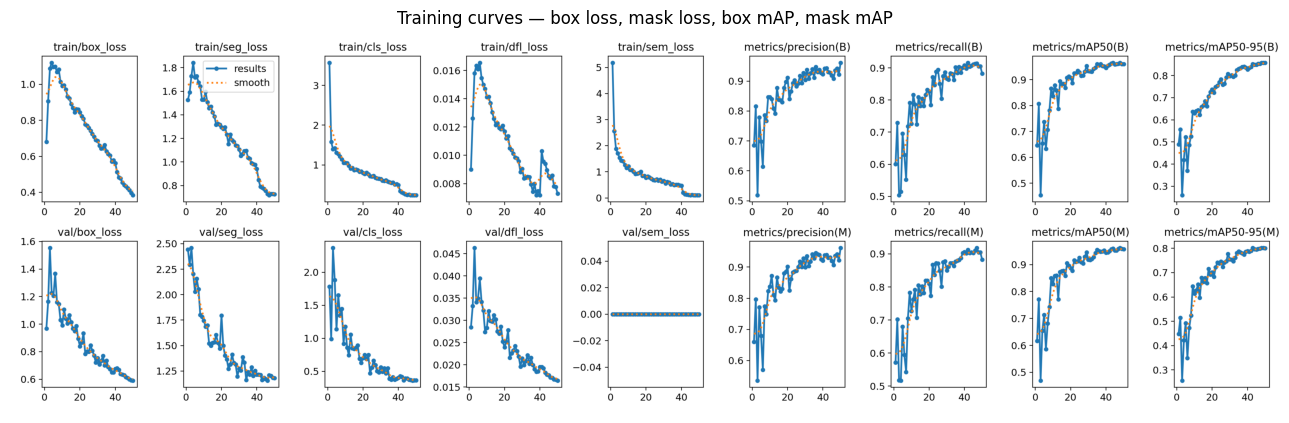

In [13]:
fig, ax = plt.subplots(figsize=(13, 10))
img = Image.open(run_dir / "results.png")
ax.imshow(img); ax.axis("off")
ax.set_title("Training curves — box loss, mask loss, box mAP, mask mAP")
plt.tight_layout(); plt.show()

## 9. Evaluation — box mAP *and* mask mAP

A `-seg` model reports **two independent sets of detection metrics on the same predictions**: `metrics.box` scores the predicted boxes exactly as in Lab 7/8, and `metrics.seg` scores the predicted masks the same way but using mask IoU instead of box IoU for matching. Compare them.

> If `metrics.seg` doesn't exist on your `ultralytics` version, inspect `dir(metrics)` — this attribute name has occasionally changed between releases.

In [14]:
from ultralytics import YOLO

best_model = YOLO(str(run_dir / "weights" / "best.pt"))

metrics = best_model.val(
    data=str(seg_yaml_path.resolve()),
    split="test",
    imgsz=640,
    device=0,
    project="runs",
    name="wildlife_detector_seg_test",
    exist_ok=True,
    verbose=False,
)

print("Box metrics (same definition as Lab 7/8):")
print(f"  mAP50:    {metrics.box.map50:.4f}")
print(f"  mAP50-95: {metrics.box.map:.4f}")

print("\nMask metrics (new this lab — same idea, IoU computed on pixels not boxes):")
print(f"  mAP50:    {metrics.seg.map50:.4f}")
print(f"  mAP50-95: {metrics.seg.map:.4f}")

Ultralytics 8.4.45 🚀 Python-3.11.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32607MiB)
YOLO26m-seg summary (fused): 149 layers, 23,510,552 parameters, 0 gradients, 121.2 GFLOPs
val: Fast image access ✅ (ping: 1.0±0.1 ms, read: 48.6±24.8 MB/s, size: 90.3 KB)
val: Scanning /workspace/labs/lab10_instance_segmentation/data/labels/test... 227 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 227/227 1.5Kit/s 0.2s<0.2s
val: New cache created: /workspace/labs/lab10_instance_segmentation/data/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 7.4it/s 2.0s0.1s
                   all        227        397      0.929      0.891      0.947      0.831       0.94      0.894      0.948      0.787
Speed: 1.1ms preprocess, 3.3ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /workspace/labs/lab10_instance_segmentation/runs/segment/runs/wildlife_d

## 10. Mask IoU from first principles

Just as Lab 8 built box IoU from scratch before trusting any library's mAP, we build **mask IoU** the same way. The definition is the same idea applied to pixels instead of rectangles: intersection area over union area — except now "area" means "count of `True` pixels", and the shapes can be any silhouette, not just axis-aligned rectangles.

In [15]:
def mask_iou(mask_a: np.ndarray, mask_b: np.ndarray) -> float:
    """IoU between two boolean masks of identical shape."""
    intersection = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    return float(intersection / union) if union > 0 else 0.0


# Self-test: two overlapping 50x50 squares, offset by 20px in both axes.
a = np.zeros((100, 100), dtype=bool); a[10:60, 10:60] = True
b = np.zeros((100, 100), dtype=bool); b[30:80, 30:80] = True
expected = (30 * 30) / (50*50 + 50*50 - 30*30)
print(f"Self-test mask IoU: {mask_iou(a, b):.3f}  (expected {expected:.3f})")

Self-test mask IoU: 0.220  (expected 0.220)


### Box IoU vs. mask IoU on a real prediction

A box can look like a great match for the ground truth while the *shape* underneath is actually a poor match — the box just doesn't have the vocabulary to say so. Let's measure both on the same predicted object and see the gap directly.

In [16]:
import cv2

def iou_xyxy(a, b):
    """Box IoU — identical to Lab 8."""
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    if inter == 0:
        return 0.0
    area_a = (a[2]-a[0]) * (a[3]-a[1]); area_b = (b[2]-b[0]) * (b[3]-b[1])
    return inter / (area_a + area_b - inter)


test_img_dir = OUT_ROOT / "images" / "test"
test_lbl_dir = OUT_ROOT / "labels" / "test"
candidates = [p for p in sorted(test_img_dir.glob("*.jpg"))
              if (test_lbl_dir / f"{p.stem}.txt").is_file()
              and read_yolo_seg_labels(test_lbl_dir / f"{p.stem}.txt")]
assert candidates, "No labelled test images found — check Section 5/6 ran correctly."
sample = candidates[0]

pred = best_model.predict(source=str(sample), device=0, conf=0.15, verbose=False)[0]
with Image.open(sample) as im:
    W, H = im.size

gt_polys = read_yolo_seg_labels(test_lbl_dir / f"{sample.stem}.txt")

if pred.boxes is not None and len(pred.boxes) > 0:
    pred_box = pred.boxes.xyxy[0].cpu().numpy().tolist()
    pred_mask = pred.masks.data[0].cpu().numpy().astype(bool)

    _, gt_pts_norm = gt_polys[0]
    gt_pts_px = gt_pts_norm * np.array([W, H])
    gt_box = [gt_pts_px[:, 0].min(), gt_pts_px[:, 1].min(),
              gt_pts_px[:, 0].max(), gt_pts_px[:, 1].max()]

    gt_mask = np.zeros((H, W), dtype=np.uint8)
    cv2.fillPoly(gt_mask, [gt_pts_px.astype(np.int32)], 1)
    gt_mask = gt_mask.astype(bool)

    # Resize predicted mask to the image resolution if the model's mask
    # output resolution differs from the source image.
    if pred_mask.shape != (H, W):
        pred_mask = cv2.resize(pred_mask.astype(np.uint8), (W, H),
                                interpolation=cv2.INTER_NEAREST).astype(bool)

    box_iou_val = iou_xyxy(pred_box, gt_box)
    mask_iou_val = mask_iou(pred_mask, gt_mask)
    print(f"Image: {sample.name}")
    print(f"Box IoU:  {box_iou_val:.3f}")
    print(f"Mask IoU: {mask_iou_val:.3f}")
    print(f"Gap (box - mask): {box_iou_val - mask_iou_val:+.3f}")
    if box_iou_val - mask_iou_val > 0.1:
        print("\nThe box overstates how well this prediction matches the object's true shape.")
else:
    print(f"No detections on {sample.name} at conf=0.25 — try a different image or lower the threshold.")

Image: img_0006.jpg
Box IoU:  0.972
Mask IoU: 0.633
Gap (box - mask): +0.339

The box overstates how well this prediction matches the object's true shape.


## 11. Inference on new images

`results[0].plot()` draws boxes, class labels, confidence scores, *and* masks in one call — the segmentation equivalent of Lab 7's saved prediction images.

Results saved to /workspace/labs/lab10_instance_segmentation/runs/segment/predict


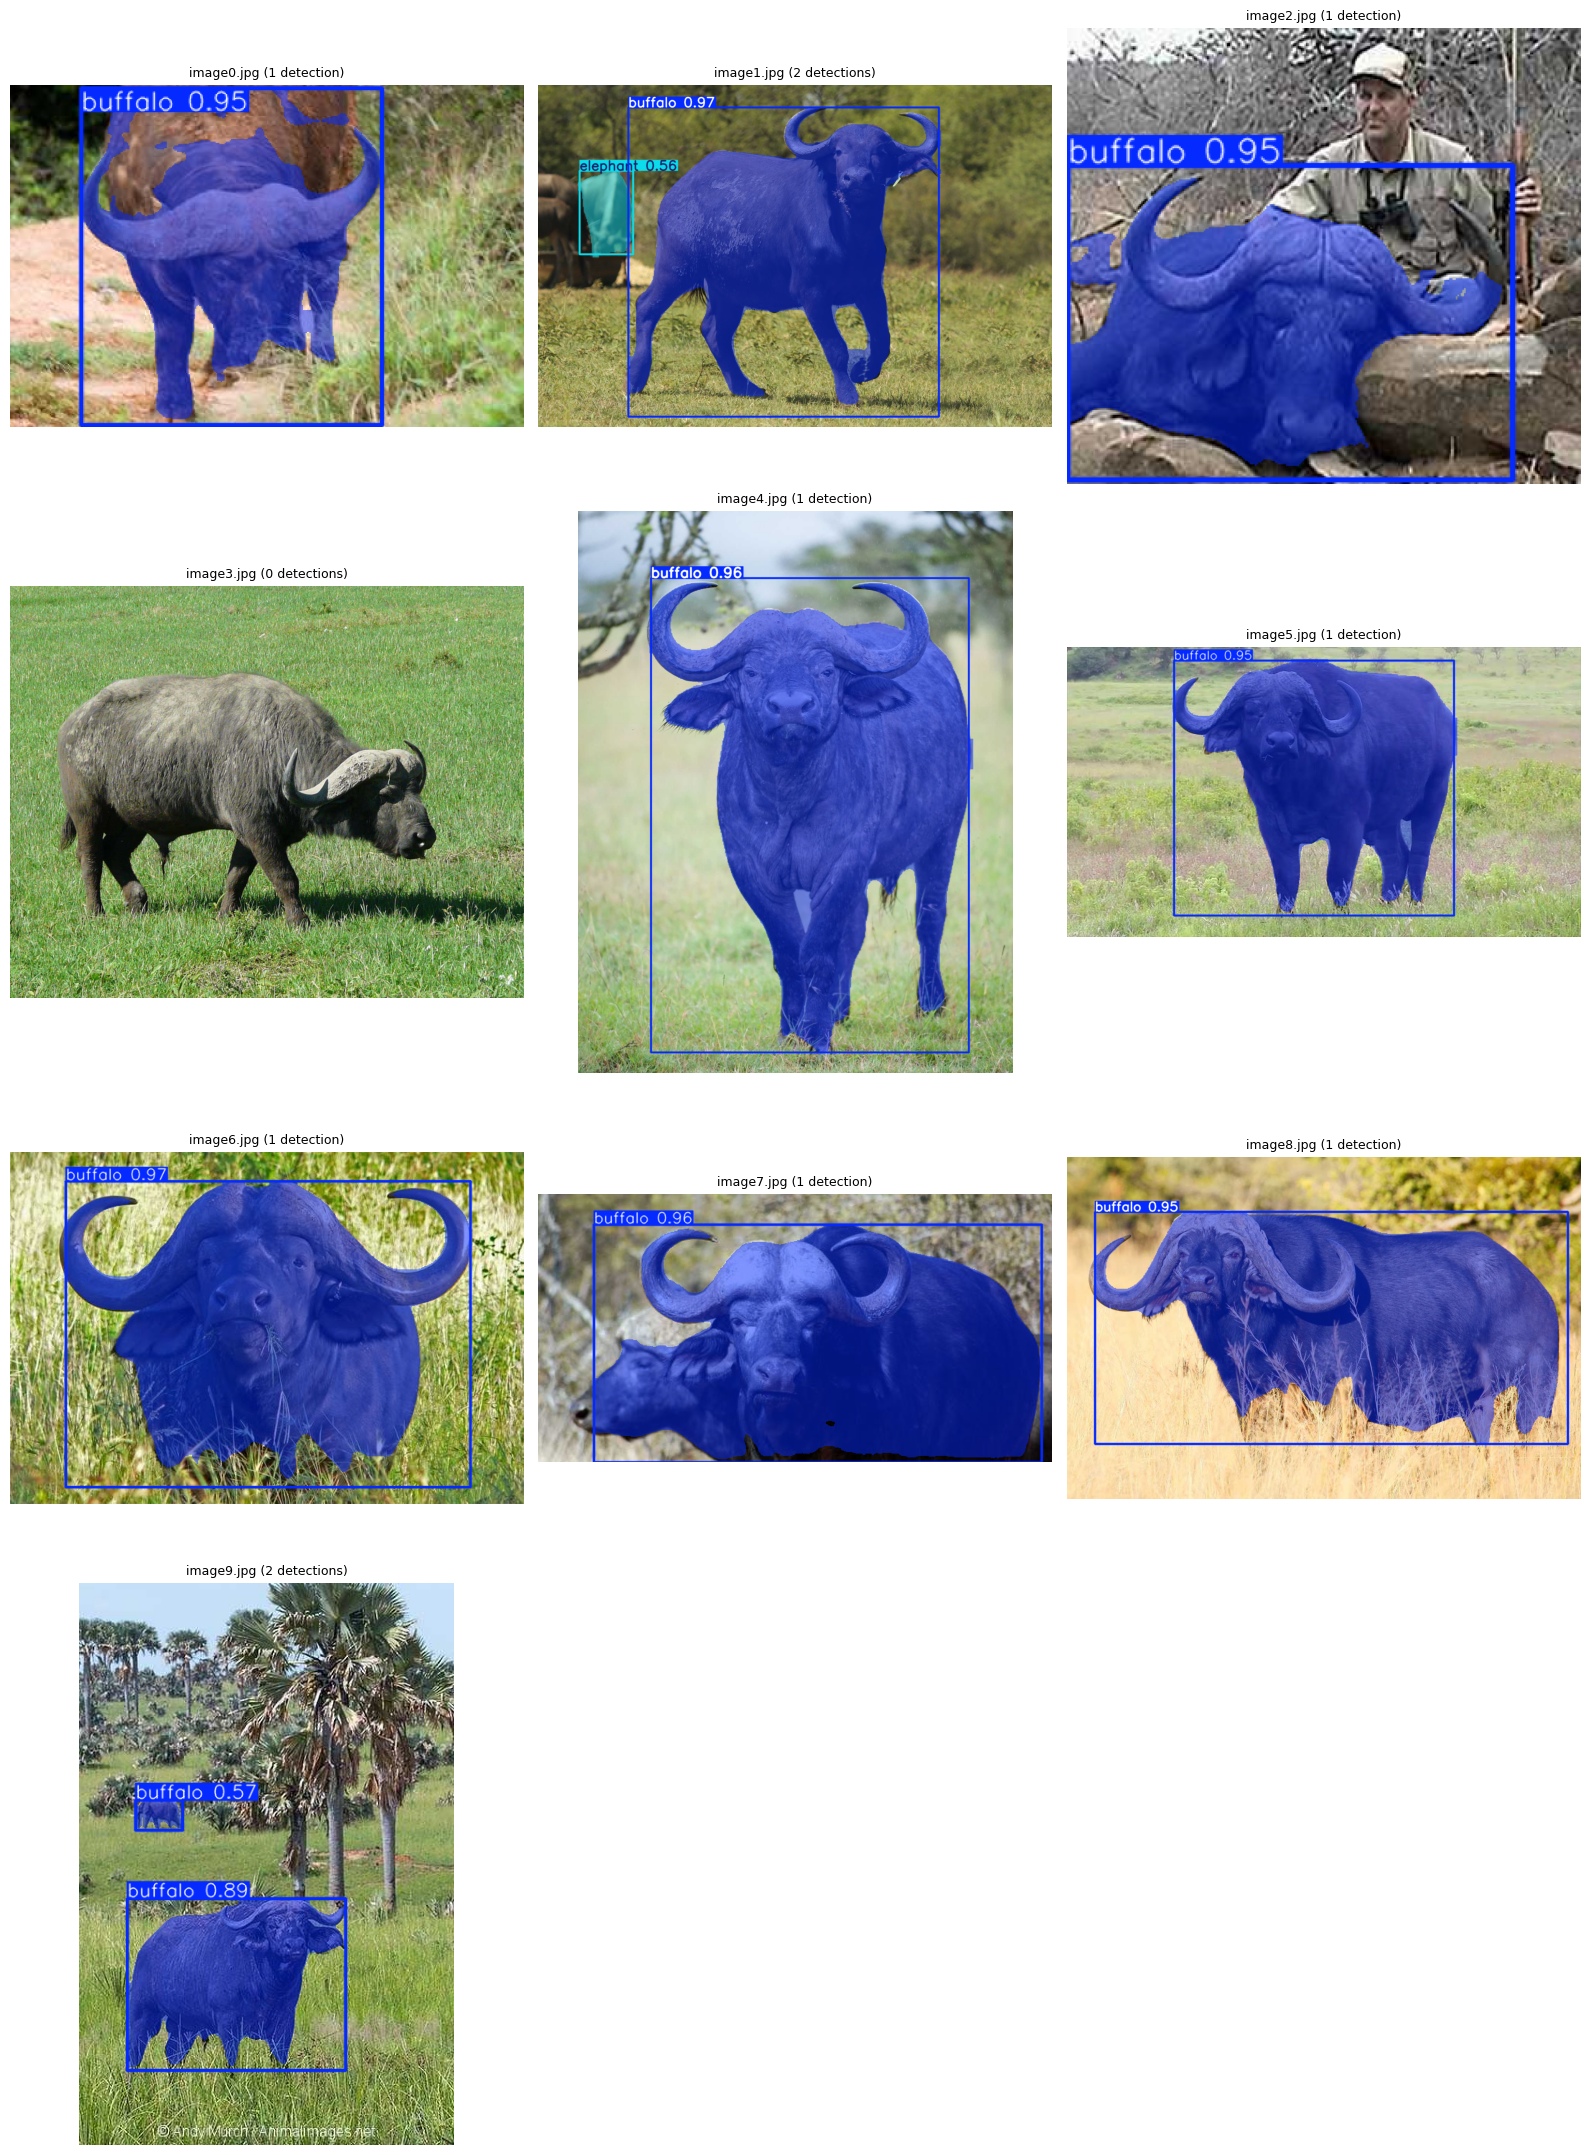

In [17]:
test_paths = sorted((OUT_ROOT / "images" / "test").glob("*.jpg"))[:10]
predictions = best_model.predict(source=[str(p) for p in test_paths], save=True,
                                  imgsz=640, conf=0.25, device=0, verbose=False)

n_cols = 3
n_rows = (len(predictions) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5.5 * n_rows))
axes = np.atleast_1d(axes).flatten()
for ax, r in zip(axes, predictions):
    plotted = r.plot()             # BGR numpy array, boxes + masks + labels
    ax.imshow(plotted[..., ::-1])  # BGR -> RGB
    ax.axis("off")
    n_det = len(r.boxes) if r.boxes is not None else 0
    ax.set_title(f"{Path(r.path).name} ({n_det} detection{'s' if n_det != 1 else ''})", fontsize=9)
for ax in axes[len(predictions):]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

---

## 12. Exercise 1 — SAM mask quality audit

Foundation-model output is a first draft, not ground truth. Audit it like one.

1. Inspect **at least 10** SAM-generated masks against their source images (reuse and extend Section 4's rendering code — loop over more stems, and over more than just the `train` split).
2. For each, judge: **good** (tight, correct silhouette), **leaky** (bleeds into background), **partial** (misses part of the animal), or **merged** (two instances collapsed into one mask).
3. Report your failure rate (masks that are *not* "good", out of the total you inspected) and describe the single most common failure mode you saw.
4. Pick **at least 3** bad masks and describe what you would change to fix them — a tighter box prompt, a point prompt instead of a box, or manual correction. If you have time, try re-running SAM with a tightened box on one of them and see if the mask improves.

In [ ]:
# Your code for Exercise 1 here.

*Your audit findings:*

**Masks inspected:**

**Failure rate:**

**Most common failure mode:**

**Three bad masks and how you would fix them:**

## 13. Exercise 2 — box IoU vs. mask IoU, quantified

Section 10 showed the box/mask IoU gap on **one** image. Now measure it systematically.

1. For every test-split image with both a prediction and a matching ground-truth instance, compute the box IoU and the mask IoU between them (adapt the matching logic from Section 10, or from Lab 8's `match_one_image`).
2. Make a scatter plot: box IoU on the x-axis, mask IoU on the y-axis, one point per matched object. Add the line `y = x` for reference.
3. Which objects sit furthest **below** the `y = x` line — i.e. where box IoU flatters the prediction most? Look at 2–3 of those images. What do they have in common (shape, pose, occlusion)?
4. Report the mean gap (`mean(box_iou - mask_iou)`) across all matched objects.

In [ ]:
# Your code for Exercise 2 here.

*Your findings, including the mean gap and what the worst-gap images had in common:*

## 14. Exercise 3 — open-ended (pick one)

**Option A — Model size trade-off.** Retrain with `yolo26s-seg.pt` and, if you have time, `yolo26x-seg.pt`. For each, record mask mAP50-95, training time, and inference time per image. Segmentation post-processing (drawing/comparing masks) is heavier than boxes — does that change your Lab 7 Exercise 2 conclusion about when a smaller model is "good enough"?

**Option B — The fully automatic pipeline.** Combine Lab 9's zero-shot YOLOE (produces boxes with *no* manual annotation) with this lab's SAM (produces masks from boxes) to build a segmentation dataset for a **new folder of unlabelled images**, with zero human-drawn boxes anywhere in the pipeline. Compare mask quality (by eye, and by mask mAP if you have any ground truth to check against) with the human-box-then-SAM-mask pipeline you built in this lab. What did you lose by removing the human from the loop?

**Option C — What masks let you measure.** Using your trained model's masks on the test split, compute each detected animal's **actual pixel area** (not box area). Discuss, in 4–6 sentences, one real wildlife-monitoring application where this area measurement is useful precisely because it comes from a mask and could not be reliably estimated from a box alone (e.g. relative body condition, distinguishing juveniles from adults, estimating distance from camera via apparent size).

In [ ]:
# Your code for Exercise 3 (Option A, B, or C) here.

*Which option did you pick, and what did you find?*

---

## 15. Reflection questions

**Q1.** In your own words, state the difference between semantic and instance segmentation, and explain why a scene of three zebras standing together in a herd needs instance rather than semantic segmentation for a wildlife-counting application.

**Q2.** SAM was never trained on your four wildlife classes, yet it produced a usable mask for an elephant it has never been told is an "elephant". Explain why this works, in terms of what SAM was actually trained to predict versus what your Lab 7 detector was trained to predict.

**Q3.** We trained on labels that were themselves produced by another model (SAM), not drawn by a human. What is the risk of this, and what is one concrete step you could take to catch a systematic labelling error before it silently degrades your trained model?

**Q4.** mAP50-95 for masks and mAP50-95 for boxes on the *same* trained model are rarely identical. Referring back to Lab 8's definition of mAP, explain in your own words what causes the two numbers to diverge.

**Q5.** A colleague argues: "We already have a good box detector from Lab 7 — segmentation isn't worth the extra training cost." Describe one wildlife-monitoring scenario where you would agree, and one where you would disagree, referencing something concrete you observed in this lab.

*Your answers:*

**A1.**

**A2.**

**A3.**

**A4.**

**A5.**

---

## What's next

You now have a model that doesn't just say "there's an elephant here, roughly" but "these exact pixels are an elephant". That precision came from a foundation model doing work that would otherwise have taken hours of manual tracing — but Section 4 and Exercise 1 also showed that its output still needed your judgement to trust.

**Lab 11** turns from *what* the model outputs to *why* it produces that output at all. You'll open up a trained CNN with Grad-CAM and saliency maps and literally see which pixels drove a prediction — including, for the malaria-cell classifier from Lab 5, whether it's really looking at the cell or at something else entirely.

Before leaving today, make sure:

- [ ] SAM-generated masks exist for every annotated box in your dataset
- [ ] You completed the mask audit in Exercise 1 and can state your SAM failure rate
- [ ] YOLO26-seg trained successfully and both box mAP and mask mAP were reported
- [ ] You completed Exercises 1, 2, and 3
- [ ] You answered the reflection questions
- [ ] Your notebook runs **top to bottom without errors**